/home/ruiqliu/conda/envs/SML/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


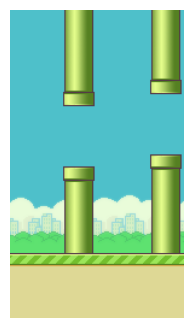

[1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         

/home/ruiqliu/conda/envs/SML/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


[1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         

In [10]:
import flappy_bird_gymnasium
import gymnasium
import matplotlib.pyplot as plt
from IPython.display import display
import time

env = gymnasium.make("FlappyBird-v0", render_mode="rgb_array", use_lidar=True)

obs, _ = env.reset()

# Initialize figure once
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")

frame = env.render()
im = ax.imshow(frame)

# Create a persistent display handle (prevents "double image" + reduces flicker)
disp = display(fig, display_id=True)

while True:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(obs)
    frame = env.render()
    if frame is None:
        raise RuntimeError("env.render() returned None; rgb_array rendering may not be supported.")

    im.set_data(frame)
    disp.update(fig)

    time.sleep(1/30)  # ~30 FPS

    if terminated or truncated:
        break

plt.close(fig)
env.close()

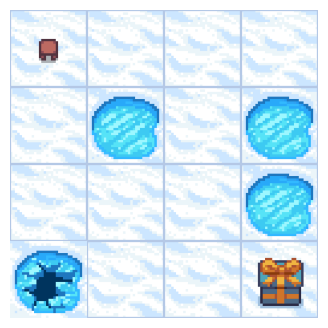

Episode 5/5 finished. total_reward=0.0


In [7]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

env = gym.make(
    "FrozenLake-v1",
    desc=None,
    map_name="4x4",
    is_slippery=True,
    success_rate=1.0/3.0,
    reward_schedule=(1, 0, 0),
    render_mode="rgb_array",   # <- key for image frames
)

episodes = 5
delay = 0.25  # seconds between frames

fig, ax = plt.subplots(figsize=(4, 4))
im = None
ax.axis("off")

for ep in range(episodes):
    obs, info = env.reset()
    terminated = truncated = False
    total_reward = 0.0

    while not (terminated or truncated):
        action = env.action_space.sample()  # random action
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        frame = env.render()  # numpy array (H, W, 3)
        if frame is None:
            raise RuntimeError(
                "env.render() returned None. Try installing pygame: `pip install pygame` "
                "and restart the kernel."
            )
        if im is None:
            im = ax.imshow(frame)
        else:
            im.set_data(frame)

        clear_output(wait=True)
        display(fig)
        time.sleep(delay)

    print(f"Episode {ep+1}/{episodes} finished. total_reward={total_reward}")

plt.close(fig)
env.close()

In [6]:
!pip install "gymnasium[toy-text]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 127.6 MB/s  0:00:00
